In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
bitacora= pd.read_csv('Analisis GAC Full7agosto 2026(Bitacora de Piso).csv') 

In [3]:
#Verificamos información del DataFrame
bitacora.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fecha                                       198 non-null    str    
 1   Nombre Cliente                              197 non-null    str    
 2   Telefono                                    0 non-null      float64
 3   Asesor                                      196 non-null    str    
 4   Esatus Lead                                 197 non-null    str    
 5   PDM                                         234 non-null    bool   
 6   SDC                                         216 non-null    object 
 7   Estatus de SDC                              2 non-null      str    
 8   Venta                                       216 non-null    object 
 9   Temperatura                                 10 non-null     str    
 10  Inter Gerente            

In [5]:
#Imprimo los primeros 5 registro del dataframe
bitacora.head()

,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,...,NaN,NaN,NaN,NaN,NaN,NaN,Items,Items,items,items
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,Aurelio,Activo,Aprobada,Lead Interes Medio
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pedro,Cerrado,Condicionada,Lead InteresBajo


Bitácora de Piso — ¿Por que no hubo Solicitud de credito?

In [6]:
# Extraigo la pregunta abierta
Pregunta_credito = bitacora[
    ["¿Por que no hubo Solicitud de credito?"]
].copy()

# Elimino las respuestas vacías
Pregunta_credito = Pregunta_credito.dropna()

Pregunta_credito

,¿Por que no hubo Solicitud de credito?
0,"El cliente acudió con una prima, para ella ser..."
1,Es una decisión que prefiere tomar con sus hijos.
2,Ingresa SDC con el perfil de ella y el de su e...
3,El cliente comenta que en este momento tiene c...
6,"Sí hubo SDC, el cliente trabaja en Santander y..."
13,El cliente comenta que compraría a través de u...
18,"Prefiere autos sedanes e insistió en esperar, ..."
25,Es compra de contado.
34,Es venta de contado
35,Porque la venta sería de contado.


In [7]:
Pregunta_credito["Caracteristica"] = "Otro"

In [8]:
Pregunta_credito.loc[

    Pregunta_credito["¿Por que no hubo Solicitud de credito?"]
    .str.contains(
        "contado",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Compra de contado"

In [9]:
Pregunta_credito.loc[

    Pregunta_credito["¿Por que no hubo Solicitud de credito?"]
    .str.contains(
        "considerando opciones|valorando opciones|revisar el proceso|esperar",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Sigue evaluando"

In [10]:
Pregunta_credito.loc[

    Pregunta_credito["¿Por que no hubo Solicitud de credito?"]
    .str.contains(
        "compromisos economicos|capacidad de pago|historial|"
        "ninguna financiera|revisando opciones",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Limitaciones económicas o financieras"

In [11]:
Pregunta_credito.loc[

    Pregunta_credito["¿Por que no hubo Solicitud de credito?"]
    .str.contains(
        "despues de que maneje|después de que maneje",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Espera otra etapa del proceso"

In [12]:
Pregunta_credito.loc[

    Pregunta_credito["¿Por que no hubo Solicitud de credito?"]
    .str.contains(
        "no quiere tramitar|tiguan|sedanes",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Prefiere otra opción"

In [13]:
Pregunta_credito.loc[

    Pregunta_credito["¿Por que no hubo Solicitud de credito?"]
    .str.contains(
        "sí hubo sdc|si hubo sdc|ingresa sdc",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Sí hubo SDC"

In [14]:
Pregunta_credito.loc[

    Pregunta_credito["¿Por que no hubo Solicitud de credito?"]
    .str.contains(
        "sus hijos|través de su mamá|traves de su mama",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Decisión o apoyo familiar"

In [15]:
Pregunta_credito

,¿Por que no hubo Solicitud de credito?,Caracteristica
0,"El cliente acudió con una prima, para ella ser...",Sigue evaluando
1,Es una decisión que prefiere tomar con sus hijos.,Decisión o apoyo familiar
2,Ingresa SDC con el perfil de ella y el de su e...,Sí hubo SDC
3,El cliente comenta que en este momento tiene c...,Limitaciones económicas o financieras
6,"Sí hubo SDC, el cliente trabaja en Santander y...",Sí hubo SDC
13,El cliente comenta que compraría a través de u...,Sigue evaluando
18,"Prefiere autos sedanes e insistió en esperar, ...",Prefiere otra opción
25,Es compra de contado.,Compra de contado
34,Es venta de contado,Compra de contado
35,Porque la venta sería de contado.,Compra de contado


In [16]:
Tabla_credito = (

    Pregunta_credito["Caracteristica"]
    .value_counts()
    .reset_index()

)

Tabla_credito

,Caracteristica,count
0,Compra de contado,4
1,Sigue evaluando,2
2,Decisión o apoyo familiar,2
3,Sí hubo SDC,2
4,Prefiere otra opción,2
5,Limitaciones económicas o financieras,1
6,Espera otra etapa del proceso,1


In [17]:
Pregunta_credito[
    Pregunta_credito["Caracteristica"] == "Otro"
]

,¿Por que no hubo Solicitud de credito?,Caracteristica


In [18]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro1= Tabla_credito[Tabla_credito['count']>1] #Filtrar los que sean mayores a 1
Filtro1

,Caracteristica,count
0,Compra de contado,4
1,Sigue evaluando,2
2,Decisión o apoyo familiar,2
3,Sí hubo SDC,2
4,Prefiere otra opción,2


In [20]:
#Ajusto el indice de mi dataframe
Filtro_index1= Filtro1.set_index('Caracteristica')
Filtro_index1

,count
Caracteristica,
Compra de contado,4
Sigue evaluando,2
Decisión o apoyo familiar,2
Sí hubo SDC,2
Prefiere otra opción,2


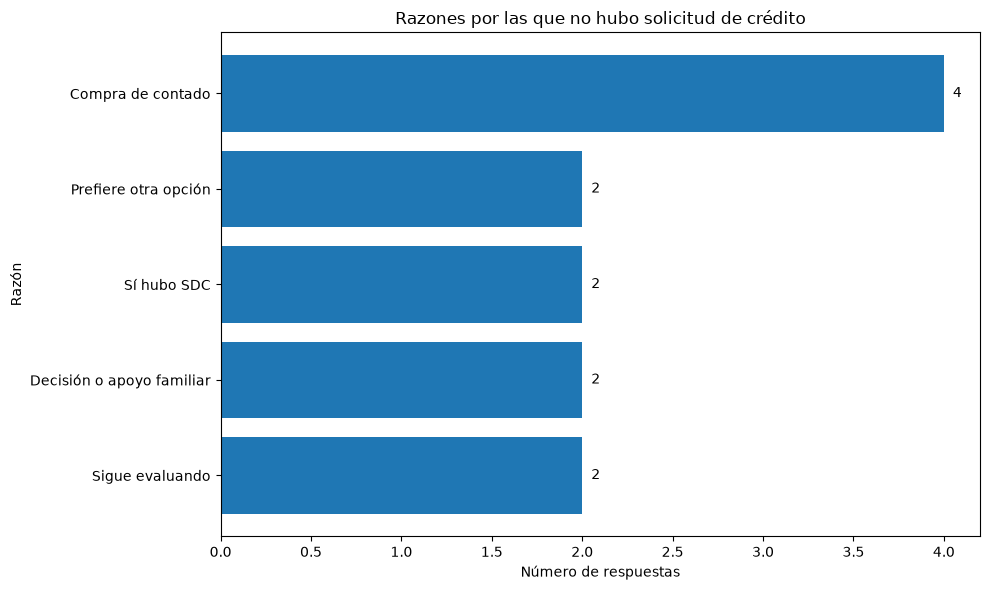

In [21]:
import matplotlib.pyplot as plt

# Ordeno las categorías de menor a mayor
Filtro_index1 = Filtro_index1.sort_values(
    by="count",
    ascending=True
)

# Creo la gráfica
plt.figure(figsize=(10, 6))

barras = plt.barh(
    Filtro_index1.index,
    Filtro_index1["count"]
)

# Agrego el número de respuestas al final de cada barra
for barra in barras:

    ancho = barra.get_width()

    plt.text(
        ancho + 0.05,
        barra.get_y() + barra.get_height()/2,
        int(ancho),
        va="center"
    )

plt.title("Razones por las que no hubo solicitud de crédito")
plt.xlabel("Número de respuestas")
plt.ylabel("Razón")

plt.tight_layout()
plt.show()